# Use case 5: `aviso listen` → email notification + visualisation

**Ask (Antonino, Ulrike):** establish a workflow that starts from the `aviso listen` command line
tool and, for every matching notification, sends an **email** and produces a **visualisation**
of the announced data.

This notebook builds that workflow as an unattended process rather than as notebook code: the
`aviso` CLI runs a listener YAML whose `command` trigger calls a small Python script,
`on_event.py`, which retrieves the field with earthkit-data (Polytope), plots it with
earthkit-plots and emails the result. The interactive, widget-driven version of the same
pipeline is in `../aviso2-lumi-extremes-dt-earthkit.ipynb`.

| Setting | Value |
| --- | --- |
| Aviso server | `https://aviso2.lumi.apps.dte.destination-earth.eu` (Aviso 2 on the LUMI data bridge) |
| Event type | `data` (identifiers `class`, `stream`, `type`, `levtype`, `date`, `time`, `step`, ...) |
| Aviso auth | Bearer token = DESP offline token from `~/.polytopeapirc` (written by `desp-authentication.py`) |
| Data | Polytope `polytope.lumi.apps.dte.destination-earth.eu` (or `polytope.mn5.apps.dte.destination-earth.eu`), dataset `extremes-dt`, server-side `area` sub-selection |
| Email | `smtplib` (`SMTP_HOST`, `SMTP_PORT`, `SMTP_USER`, `SMTP_PASSWORD`) or local `sendmail`; `EMAIL_DRY_RUN=1` prints instead |
| Recipient | `ulrike.falk@ecmwf.int` (default of `--to`) |
| Client | `pip install pyaviso earthkit-data earthkit-plots` (`aviso` 2.1.0 CLI ships with `pyaviso`) |

```
aviso listen listener.yaml
   │   watch /api/v1/watch, filter class=d1 stream=oper type=fc levtype=sfc step=0
   ▼
command trigger  ── {{ notification.identifier.* }} templates + AVISO_* env vars ──►  on_event.py
                                                                                     ├─ earthkit.data.from_source("polytope", ...)   retrieve GRIB (area box, ~2.3 MB)
                                                                                     ├─ earthkit.plots.Map(domain).quickplot(...)   PNG
                                                                                     └─ EmailMessage + smtplib / sendmail            email (PNG attached)
```

Sections:

1. Setup
2. The handler script `on_event.py`
3. Standalone test of the handler (dry-run email, one real retrieval)
4. Listener YAML with `echo`, `log` and `command` triggers
5. CLI configuration and authentication
6. `aviso replay` with triggers (bounded, exercises the failure-email path)
7. `aviso listen` live, time-bounded
8. Running it as a service, notes

## 1. Setup

Everything this notebook writes goes to `uc05/` next to it: the handler script, the listener
YAML, a CLI config file, state files and an `output/` folder with GRIB, PNG and log files.

In [1]:
import json
import os
import pathlib
import shutil
import subprocess
import sys
import time
from datetime import datetime, timedelta, timezone

import pyaviso
from IPython.display import Image, display

BASE_URL = os.environ.get("AVISO_BASE_URL", "https://aviso2.lumi.apps.dte.destination-earth.eu").rstrip("/")
EVENT = "data"
EMAIL_TO = "ulrike.falk@ecmwf.int"

WORK = pathlib.Path("uc05").resolve()
OUT_DIR = WORK / "output"
OUT_DIR.mkdir(parents=True, exist_ok=True)

# Housekeeping: earlier full-field runs left ~50 MB GRIBs here; drop them and keep only the newest PNG.
for g in OUT_DIR.glob("*.grib"):
    if g.stat().st_size > 20_000_000:
        g.unlink()
        print("removed stale full-field GRIB", g.name)
pngs = sorted(OUT_DIR.glob("*.png"), key=lambda q: q.stat().st_mtime)
for q in pngs[:-1]:
    q.unlink()

SCRIPT = WORK / "on_event.py"
LISTENER = WORK / "listener.yaml"
CLI_CONFIG = WORK / "aviso-config.yaml"
PYTHON = sys.executable                      # the kernel's interpreter has earthkit installed
AVISO_BIN = shutil.which("aviso") or str(pathlib.Path(PYTHON).parent / "aviso")

print("pyaviso", pyaviso.__version__, "| aviso CLI:", AVISO_BIN, "| python:", PYTHON)
print("work dir:", WORK)

pyaviso 2.1.0 | aviso CLI: /opt/homebrew/Caskroom/mambaforge/base/envs/aviso/bin/aviso | python: /opt/homebrew/Caskroom/mambaforge/base/envs/aviso/bin/python
work dir: /Users/mauf/Git/aviso/jupyter/use-cases/uc05


## 2. The handler script `on_event.py`

One notification → one process. The script takes the notification fields as command line
arguments (the trigger fills them from `{{ notification.identifier.* }}`), then:

1. builds the Polytope request (`dataset: extremes-dt`, the identifier keys, `param` from the
   argument, default 167 = 2 m temperature). `--area N/W/S/E` adds a MARS-style `area` key so
   Polytope cuts the box server-side (a 72N-30N / 25W-45E Europe box is ~2.3 MB instead of ~50 MB for the
   global field), `--grid O320` adds server-side interpolation to a coarser octahedral grid;
   `--address` switches between the LUMI and MN5 data bridges;
2. writes the GRIB and a PNG map (`earthkit.plots.Map(domain=...)`) into `--out-dir`;
3. emails a summary with the PNG attached. If the retrieval fails the email is still sent, with
   the error in the body (`--no-fail-email` turns that off), so a data arrival is never silent.

Email transport is decided from the environment: `EMAIL_DRY_RUN=1` prints the message,
`SMTP_HOST` selects `smtplib` with STARTTLS (and login when `SMTP_USER` is set), otherwise the
message is piped to `/usr/sbin/sendmail -t`. The script exits 0 whenever the email step
succeeded, so a failed retrieval does not stop the listener; a failed email exits 1 and, with
`required: false` on the trigger, is logged as a warning by `aviso`.

In [2]:
SCRIPT_SOURCE = r'''#!/usr/bin/env python3
# Aviso command-trigger handler: retrieve the announced Extremes-DT field, plot it, email it.
#
# Called by `aviso listen`/`aviso replay` through a `command` trigger, e.g.
#   on_event.py --date 20260923 --time 0000 --step 0 --stream oper --levtype sfc --sequence 42
# Environment: EMAIL_DRY_RUN=1 | SMTP_HOST[,SMTP_PORT,SMTP_USER,SMTP_PASSWORD,SMTP_STARTTLS] | sendmail fallback.
import argparse
import json
import os
import pathlib
import shutil
import smtplib
import subprocess
import sys
import time
import traceback
from datetime import datetime, timezone
from email.message import EmailMessage
from email.utils import formatdate, make_msgid

ADDRESSES = {"lumi": "polytope.lumi.apps.dte.destination-earth.eu", "mn5": "polytope.mn5.apps.dte.destination-earth.eu"}
DATASET = "extremes-dt"


def parse_args():
    p = argparse.ArgumentParser(description="Aviso trigger handler: retrieve, plot and email an Extremes-DT field.")
    p.add_argument("--date", required=True, help="YYYYMMDD")
    p.add_argument("--time", required=True, help="HHMM or HH")
    p.add_argument("--step", required=True)
    p.add_argument("--stream", default="oper")
    p.add_argument("--levtype", default="sfc")
    p.add_argument("--type", dest="type_", default="fc")
    p.add_argument("--expver", default="0001")
    p.add_argument("--param", default="167", help="paramId, default 167 (2 m temperature)")
    p.add_argument("--levelist", default=None, help="needed for levtype pl/hl")
    p.add_argument("--area", default=None, help="server-side sub-area N/W/S/E, e.g. 72/-25/30/45 (Europe)")
    p.add_argument("--grid", default=None, help="server-side interpolation target grid, e.g. O320 (O, F, N grids)")
    p.add_argument("--address", default="lumi", help="data bridge: lumi | mn5 | full hostname")
    p.add_argument("--domain", default="Europe", help="earthkit-plots domain name, or 'Global'")
    p.add_argument("--to", default="ulrike.falk@ecmwf.int")
    p.add_argument("--sender", default=os.environ.get("EMAIL_FROM"))
    p.add_argument("--out-dir", default="output")
    p.add_argument("--sequence", default=os.environ.get("AVISO_SEQUENCE", "?"))
    p.add_argument("--event-type", default=os.environ.get("AVISO_EVENT_TYPE", "data"))
    p.add_argument("--no-email", action="store_true")
    p.add_argument("--no-fail-email", action="store_true", help="do not email when the retrieval failed")
    return p.parse_args()


def build_request(a):
    req = {"class": "d1", "dataset": DATASET, "expver": a.expver, "stream": a.stream, "type": a.type_,
           "levtype": a.levtype, "date": a.date, "time": a.time, "step": str(a.step), "param": a.param}
    if a.levelist:
        req["levelist"] = a.levelist
    if a.area:
        n, w, s_, e = (float(x) for x in a.area.split("/"))
        req["area"] = [n, w, s_, e]                 # MARS convention: North/West/South/East
    if a.grid:
        req["grid"] = a.grid
    return req


def file_stem(req):
    stem = "{stream}_{levtype}_{param}_{date}_{time}_step{step}".format(**req)
    if "area" in req:
        stem += "_area" + "_".join(f"{v:g}" for v in req["area"]).replace("-", "m")
    if "grid" in req:
        stem += "_" + req["grid"]
    return stem


def retrieve_and_plot(req, domain, out_dir, address):
    import matplotlib
    matplotlib.use("Agg")
    import earthkit.data as ekd
    import earthkit.plots as ekp

    stem = file_stem(req)
    data = ekd.from_source("polytope", "destination-earth", req, address=address, stream=False)
    fields = data.to_fieldlist() if hasattr(data, "to_fieldlist") else data
    grib = out_dir / f"{stem}.grib"
    fields.to_target("file", str(grib))
    chart = ekp.Map(domain=None if domain == "Global" else domain)
    chart.quickplot(fields[0])
    chart.coastlines()
    chart.gridlines()
    chart.legend()
    chart.title("Extremes-DT {variable_name}, valid {valid_time:%Y-%m-%d %H:%M} (T+{step})")
    png = out_dir / f"{stem}_{domain.replace(' ', '')}.png"
    chart.save(png)
    return grib, png, f"{fields[0].metadata('name')} ({grib.stat().st_size / 1024:.0f} kB GRIB)"


def compose(a, req, png, error):
    ok = error is None
    subject = ("[Aviso] Extremes-DT {stream}/{levtype} {date} {time}Z step {step} "
               + ("available" if ok else "announced (retrieval failed)")).format(**req)
    lines = [f"Aviso '{a.event_type}' notification (sequence {a.sequence}) from the LUMI data bridge.", "",
             "identifier:", *[f"  {k:<8} {req[k]}" for k in ("class", "stream", "type", "levtype", "date", "time", "step")],
             "", "Polytope request:", "  " + json.dumps(req), ""]
    if ok:
        lines += [f"Map attached: {png.name}"]
    else:
        lines += ["Retrieval/plot failed:", "  " + error]
    lines += ["", f"sent by on_event.py at {datetime.now(timezone.utc):%Y-%m-%d %H:%M:%S} UTC"]
    msg = EmailMessage()
    msg["Subject"], msg["From"], msg["To"] = subject, a.sender or a.to, a.to
    msg["Date"], msg["Message-ID"] = formatdate(localtime=True), make_msgid()
    msg.set_content("\n".join(lines))
    if ok and png and png.exists():
        msg.add_attachment(png.read_bytes(), maintype="image", subtype="png", filename=png.name)
    return msg


def send(msg):
    if os.environ.get("EMAIL_DRY_RUN", "0") == "1":
        print("EMAIL_DRY_RUN=1 -> not sending. Message (headers + text part):")
        for h in ("From", "To", "Subject", "Date"):
            print(f"  {h}: {msg[h]}")
        body = msg.get_body(preferencelist=("plain",))
        print("  " + (body.get_content() if body else "").replace("\n", "\n  "))
        print("  attachments:", [p.get_filename() for p in msg.iter_attachments()])
        return "dry-run"
    host = os.environ.get("SMTP_HOST")
    if host:
        port = int(os.environ.get("SMTP_PORT", "587"))
        user, password = os.environ.get("SMTP_USER"), os.environ.get("SMTP_PASSWORD")
        with smtplib.SMTP(host, port, timeout=30) as smtp:
            if os.environ.get("SMTP_STARTTLS", "1") == "1":
                smtp.starttls()
            if user:
                smtp.login(user, password or "")
            smtp.send_message(msg)
        return f"smtp://{host}:{port}"
    sendmail = shutil.which("sendmail") or "/usr/sbin/sendmail"
    if pathlib.Path(sendmail).exists():
        subprocess.run([sendmail, "-t", "-oi"], input=msg.as_bytes(), check=True, timeout=60)
        return f"{sendmail} (local MTA; delivery depends on its relay configuration)"
    raise RuntimeError("no mail transport: set SMTP_HOST or EMAIL_DRY_RUN=1, or install sendmail")


def main():
    a = parse_args()
    out_dir = pathlib.Path(a.out_dir)
    out_dir.mkdir(parents=True, exist_ok=True)
    log = out_dir / "on_event.log"
    req = build_request(a)
    t0 = time.monotonic()
    png, error = None, None
    address = ADDRESSES.get(a.address, a.address)
    try:
        grib, png, name = retrieve_and_plot(req, a.domain, out_dir, address)
        print(f"retrieved {name} -> {grib.name}, {png.name} in {time.monotonic() - t0:.1f}s")
    except Exception as exc:                        # noqa: BLE001 - report anything, keep the listener alive
        error = f"{type(exc).__name__}: {str(exc).splitlines()[0][:300]}"
        print("retrieval/plot failed:", error, file=sys.stderr)
    status = "ok" if error is None else "retrieval-failed"
    if not a.no_email and (error is None or not a.no_fail_email):
        try:
            via = send(compose(a, req, png, error))
            print(f"email -> {a.to} via {via}")
        except Exception as exc:                    # noqa: BLE001
            status += "+email-failed"
            print("email failed:", f"{type(exc).__name__}: {exc}", file=sys.stderr)
    with log.open("a", encoding="utf-8") as fh:
        fh.write(json.dumps({"ts": datetime.now(timezone.utc).isoformat(timespec="seconds"), "sequence": a.sequence,
                             "status": status, "request": req, "png": str(png) if png else None, "error": error}) + "\n")
    sys.exit(0 if "email-failed" not in status else 1)


if __name__ == "__main__":
    main()
'''
SCRIPT.write_text(SCRIPT_SOURCE, encoding="utf-8")
SCRIPT.chmod(0o755)
print(f"wrote {SCRIPT} ({len(SCRIPT_SOURCE.splitlines())} lines)")
print(subprocess.run([PYTHON, str(SCRIPT), "--help"], capture_output=True, text=True,
                     env={**os.environ, "PYTHON_COLORS": "0", "NO_COLOR": "1"}).stdout)

wrote /Users/mauf/Git/aviso/jupyter/use-cases/uc05/on_event.py (172 lines)
usage: on_event.py [-h] --date DATE --time TIME --step STEP [--stream STREAM]
                   [--levtype LEVTYPE] [--type TYPE_] [--expver EXPVER]
                   [--param PARAM] [--levelist LEVELIST] [--area AREA]
                   [--grid GRID] [--address ADDRESS] [--domain DOMAIN]
                   [--to TO] [--sender SENDER] [--out-dir OUT_DIR]
                   [--sequence SEQUENCE] [--event-type EVENT_TYPE]
                   [--no-email] [--no-fail-email]

Aviso trigger handler: retrieve, plot and email an Extremes-DT field.

options:
  -h, --help            show this help message and exit
  --date DATE           YYYYMMDD
  --time TIME           HHMM or HH
  --step STEP
  --stream STREAM
  --levtype LEVTYPE
  --type TYPE_
  --expver EXPVER
  --param PARAM         paramId, default 167 (2 m temperature)
  --levelist LEVELIST   needed for levtype pl/hl
  --area AREA           server-side sub-area N/

## 3. Standalone test of the handler

Before wiring the script to `aviso`, run it by hand for a recent base time (yesterday 00 UTC,
step 0, 2 m temperature) with `EMAIL_DRY_RUN=1` and a Europe `--area 72/-25/30/45`. This
performs one real Polytope retrieval and prints the email instead of sending it. For
comparison: the same request without `area` returned the full global 4.4 km field, a
51 570 476-byte GRIB that took about 20 s to download (measured in an earlier run of this
notebook); the server-side box is a small fraction of that.

In [3]:
yesterday = (datetime.now(timezone.utc) - timedelta(days=1)).strftime("%Y%m%d")
env = {**os.environ, "EMAIL_DRY_RUN": "1", "MPLBACKEND": "Agg"}
t0 = time.monotonic()
run = subprocess.run(
    [PYTHON, str(SCRIPT), "--date", yesterday, "--time", "0000", "--step", "0", "--stream", "oper",
     "--levtype", "sfc", "--param", "167", "--domain", "Europe", "--area", "72/-25/30/45",
     "--to", EMAIL_TO, "--out-dir", str(OUT_DIR), "--sequence", "manual-test"],
    env=env, capture_output=True, text=True, timeout=600,
)
print(f"exit code {run.returncode} after {time.monotonic() - t0:.1f}s\n")
print(run.stdout)
stderr_lines = [l for l in run.stderr.splitlines() if "MB/s" not in l and l.strip()]
print("\n".join(stderr_lines[-8:]))

exit code 0 after 30.7s

retrieved 2 metre temperature (2297 kB GRIB) -> oper_sfc_167_20260923_0000_step0_area72_m25_30_45.grib, oper_sfc_167_20260923_0000_step0_area72_m25_30_45_Europe.png in 30.1s
EMAIL_DRY_RUN=1 -> not sending. Message (headers + text part):
  From: ulrike.falk@ecmwf.int
  To: ulrike.falk@ecmwf.int
  Subject: [Aviso] Extremes-DT oper/sfc 20260923 0000Z step 0 available
  Date: Thu, 24 Sep 2026 17:49:32 +0200
  Aviso 'data' notification (sequence manual-test) from the LUMI data bridge.
  
  identifier:
    class    d1
    stream   oper
    type     fc
    levtype  sfc
    date     20260923
    time     0000
    step     0
  
  Polytope request:
    {"class": "d1", "dataset": "extremes-dt", "expver": "0001", "stream": "oper", "type": "fc", "levtype": "sfc", "date": "20260923", "time": "0000", "step": "0", "param": "167", "area": [72.0, -25.0, 30.0, 45.0]}
  
  Map attached: oper_sfc_167_20260923_0000_step0_area72_m25_30_45_Europe.png
  
  sent by on_event.py at 2026-0

oper_sfc_167_20260923_0000_step0_area72_m25_30_45.grib: 2,351,719 bytes = 4.56% of the full field


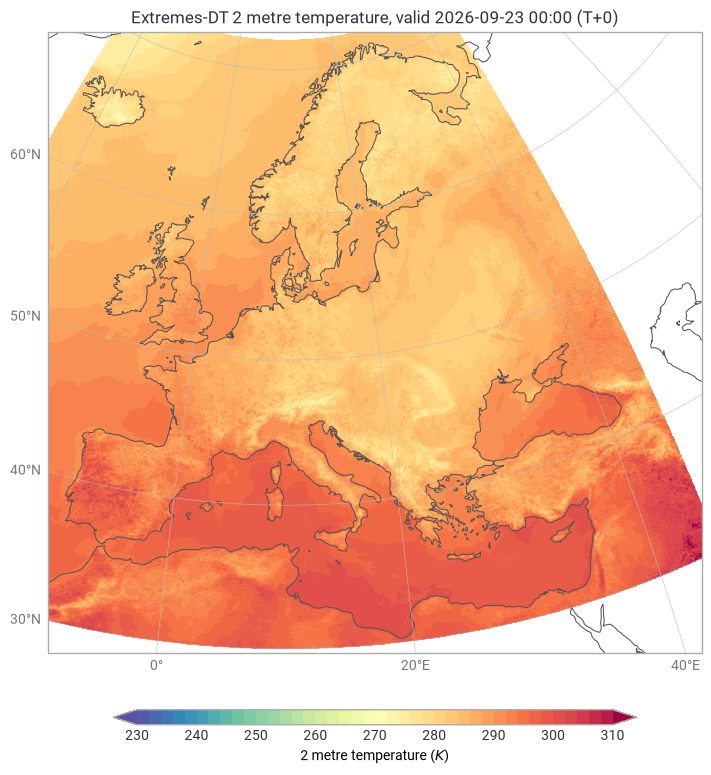

In [4]:
FULL_FIELD_BYTES = 51_570_476          # measured: same request without `area`, 2026-09-24
gribs = sorted(OUT_DIR.glob(f"oper_sfc_167_{yesterday}_0000_step0_area*.grib"))
for g in gribs:
    print(f"{g.name}: {g.stat().st_size:,} bytes = {g.stat().st_size / FULL_FIELD_BYTES:.2%} of the full field")
pngs = sorted(OUT_DIR.glob(f"oper_sfc_167_{yesterday}_0000_step0_area*.png"))
if pngs:
    display(Image(filename=str(pngs[-1]), width=640))
else:
    print("no PNG produced; see the output above")

## 4. Listener YAML

The listener subscribes to `data` on the LUMI server for `class=d1, stream=oper, type=fc,
levtype=sfc, step=0` (one notification per forecast run) and attaches three triggers:

* `echo` writes each notification to stdout (compact JSON when piped);
* `log` appends NDJSON to `output/events.ndjson`, the audit trail of what was announced;
* `command` runs `on_event.py` with the identifier fields substituted by the template engine
  (`{{ notification.identifier.date }}`, ...). `required: false` keeps the listener alive if the
  handler exits non-zero, `timeout: 10m` bounds a slow retrieval, and `exec` makes the timeout
  kill reach the Python process itself.

`--area 72/-25/30/45` keeps every retrieval to the Europe box (~2.3 MB) instead of the 50 MB
global field. Change `step` (or drop it) to react to more steps; each match starts one handler
process, so see the quota notes in section 8 before widening the filter.

In [5]:
LISTENER_YAML = f'''listeners:
  - name: extremes-dt-sfc-step0
    event: {EVENT}
    identifiers:
      class: d1
      stream: oper
      type: fc
      levtype: sfc
      step: 0
    triggers:
      - type: echo
      - type: log
        path: {OUT_DIR}/events.ndjson
      - type: command
        command: >-
          exec {PYTHON} {SCRIPT}
          --date {{{{ notification.identifier.date }}}}
          --time {{{{ notification.identifier.time }}}}
          --step {{{{ notification.identifier.step }}}}
          --stream {{{{ notification.identifier.stream }}}}
          --levtype {{{{ notification.identifier.levtype }}}}
          --param 167 --area 72/-25/30/45 --domain Europe --to {EMAIL_TO}
          --out-dir {OUT_DIR}
          --sequence {{{{ notification.sequence }}}}
          >> {OUT_DIR}/on_event.stdout 2>&1
        working_dir: {WORK}
        timeout: 10m
        required: false
        retries: 0
'''
LISTENER.write_text(LISTENER_YAML, encoding="utf-8")
print(LISTENER_YAML)

listeners:
  - name: extremes-dt-sfc-step0
    event: data
    identifiers:
      class: d1
      stream: oper
      type: fc
      levtype: sfc
      step: 0
    triggers:
      - type: echo
      - type: log
        path: /Users/mauf/Git/aviso/jupyter/use-cases/uc05/output/events.ndjson
      - type: command
        command: >-
          exec /opt/homebrew/Caskroom/mambaforge/base/envs/aviso/bin/python /Users/mauf/Git/aviso/jupyter/use-cases/uc05/on_event.py
          --date {{ notification.identifier.date }}
          --time {{ notification.identifier.time }}
          --step {{ notification.identifier.step }}
          --stream {{ notification.identifier.stream }}
          --levtype {{ notification.identifier.levtype }}
          --param 167 --area 72/-25/30/45 --domain Europe --to ulrike.falk@ecmwf.int
          --out-dir /Users/mauf/Git/aviso/jupyter/use-cases/uc05/output
          --sequence {{ notification.sequence }}
          >> /Users/mauf/Git/aviso/jupyter/use-cases/uc05/o

## 5. CLI configuration and authentication

`aviso` resolves settings as flags > environment > config file. The user's default config
(`~/.config/aviso/config.yaml`) points at the playground with an ECMWF key, so this notebook
passes its own minimal config (`base_url` only) with `-c` and injects the DESP offline token
through `AVISO_TOKEN` in the subprocess environment. The token is read from
`~/.polytopeapirc` (`user_key`, written by `desp-authentication.py`) and never printed. A
dedicated `AVISO_STATE_FILE` keeps these runs from touching real resume cursors.

In [6]:
CLI_CONFIG.write_text(f'base_url: "{BASE_URL}"\n', encoding="utf-8")


def aviso_token():
    if os.environ.get("AVISO_TOKEN"):
        return os.environ["AVISO_TOKEN"]
    rc = pathlib.Path.home() / ".polytopeapirc"
    if rc.exists():
        key = json.loads(rc.read_text(encoding="utf-8")).get("user_key")
        if key:
            return key
    raise RuntimeError("no token: set AVISO_TOKEN or run desp-authentication.py to create ~/.polytopeapirc")


TOKEN = aviso_token()
CLI_ENV = {**os.environ, "AVISO_BASE_URL": BASE_URL, "AVISO_TOKEN": TOKEN,
           "AVISO_CLIENT_CONFIG_FILE": str(CLI_CONFIG), "EMAIL_DRY_RUN": "1", "MPLBACKEND": "Agg",
           "NO_COLOR": "1"}


def aviso_cli(*args, timeout=120, env=CLI_ENV, show=True):
    cmd = [AVISO_BIN, "-c", str(CLI_CONFIG), *args]
    run = subprocess.run(cmd, env=env, capture_output=True, text=True, timeout=timeout, cwd=str(WORK))
    if show:
        print("$ aviso", " ".join(str(a) for a in args))
        if run.stdout.strip():
            print(run.stdout.rstrip())
        if run.stderr.strip():
            print(run.stderr.rstrip())
        print(f"(exit {run.returncode})")
    return run


print(f"token loaded ({len(TOKEN)} chars) for {BASE_URL}")
_ = aviso_cli("--version")
_ = aviso_cli("schema", "list")
_ = aviso_cli("schema", "get", EVENT)

token loaded (605 chars) for https://aviso2.lumi.apps.dte.destination-earth.eu
$ aviso --version
aviso 2.1.0
(exit 0)


$ aviso schema list
{"event_type":"data"}
(exit 0)


$ aviso schema get data
{
  "event_type": "data",
  "schema": {
    "identifier": {
      "class": {
        "max_length": 2,
        "required": true,
        "type": "StringHandler"
      },
      "date": {
        "canonical_format": "%Y%m%d",
        "required": false,
        "type": "DateHandler"
      },
      "domain": {
        "required": false,
        "type": "EnumHandler",
        "values": [
          "g"
        ]
      },
      "expver": {
        "default": "0001",
        "required": false,
        "type": "ExpverHandler"
      },
      "levtype": {
        "required": false,
        "type": "EnumHandler",
        "values": [
          "sfc",
          "pl",
          "hl"
        ]
      },
      "step": {
        "range": [
          0,
          10000
        ],
        "required": false,
        "type": "IntHandler"
      },
      "stream": {
        "required": false,
        "type": "EnumHandler",
        "values": [
          "wave",
          "oper"
        ]


## 6. `aviso replay` with triggers (bounded)

`aviso replay <yaml> --from <sequence>` runs the same triggers over stored history and exits at
`replay_completed`, which makes it the natural integration test of the workflow. The server
capped replays at 10 000 notifications, so the cursor is placed a little before the newest
sequence (found by bisection with the Python client).

**What to expect:** the LUMI stream currently holds a back-fill of forecast dates published
on 2026-09-16 (nothing newer). Polytope serves roughly the last two weeks, so replayed
announcements inside that window take the *success* path (GRIB + PNG + email with the map
attached) and older ones take the *failure* path (email saying the data was announced and why
the retrieval failed). `EMAIL_DRY_RUN=1` is set for this cell so the replay produces printed
emails, not real ones; with the `area` box each match costs one small retrieval.

In [7]:
client = pyaviso.AvisoClient(base_url=BASE_URL, auth=pyaviso.Bearer(TOKEN))


def has_after(seq, filter={"class": "d1"}):
    with client.listen(EVENT, filter=filter, start_from=seq, mode="replay_only") as s:
        return next(iter(s), None) is not None


def latest_sequence():
    lo, hi = 0, 1
    while has_after(hi):
        lo, hi = hi, hi * 2
    while hi - lo > 1:
        mid = (lo + hi) // 2
        if has_after(mid):
            lo = mid
        else:
            hi = mid
    return lo + 1


latest = latest_sequence()
REPLAY_FROM = max(latest - 1200, 1)
print(f"newest sequence on {EVENT}: {latest}; replaying triggers from {REPLAY_FROM}")

for f in (OUT_DIR / "events.ndjson", OUT_DIR / "on_event.stdout", OUT_DIR / "on_event.log"):
    f.unlink(missing_ok=True)
state_replay = WORK / "state-replay.json"
state_replay.unlink(missing_ok=True)

t0 = time.monotonic()
run = aviso_cli("replay", "--state-file", str(state_replay), "--from", str(REPLAY_FROM), str(LISTENER),
                timeout=900, show=False)
print(f"aviso replay finished in {time.monotonic() - t0:.1f}s (exit {run.returncode})")
print("\n".join(run.stderr.strip().splitlines()[-6:]))

newest sequence on data: 139690; replaying triggers from 138490


aviso replay finished in 104.5s (exit 0)
Replaying extremes-dt-sfc-step0 [data] (class=d1, levtype=sfc, step=0, stream=oper, type=fc) from sequence #138490. Press Ctrl+C to stop.
Replay complete. 3 notifications delivered.


In [8]:
events = (OUT_DIR / "events.ndjson").read_text(encoding="utf-8").splitlines() if (OUT_DIR / "events.ndjson").exists() else []
print(f"log trigger: {len(events)} notification(s) matched the listener filter")
for line in events[-3:]:
    n = json.loads(line)
    print("  ", n.get("sequence"), n.get("identifier"))

log = (OUT_DIR / "on_event.log").read_text(encoding="utf-8").splitlines() if (OUT_DIR / "on_event.log").exists() else []
print(f"\ncommand trigger: on_event.py ran {len(log)} time(s)")
for line in log[-3:]:
    r = json.loads(line)
    print("  ", r["sequence"], r["status"], "|", (r["error"] or "ok")[:110])

stdout = (OUT_DIR / "on_event.stdout").read_text(encoding="utf-8") if (OUT_DIR / "on_event.stdout").exists() else ""
print("\nlast handler output (dry-run email):")
print("\n".join(stdout.strip().splitlines()[-16:]))

log trigger: 3 notification(s) matched the listener filter
   138530 {'class': 'd1', 'date': '20260913', 'domain': 'g', 'expver': '0001', 'levtype': 'sfc', 'step': '0', 'stream': 'oper', 'time': '0000', 'type': 'fc'}
   138913 {'class': 'd1', 'date': '20260914', 'domain': 'g', 'expver': '0001', 'levtype': 'sfc', 'step': '0', 'stream': 'oper', 'time': '0000', 'type': 'fc'}
   139312 {'class': 'd1', 'date': '20260915', 'domain': 'g', 'expver': '0001', 'levtype': 'sfc', 'step': '0', 'stream': 'oper', 'time': '0000', 'type': 'fc'}

command trigger: on_event.py ran 3 time(s)
   138530 ok | ok
   138913 ok | ok
   139312 ok | ok

last handler output (dry-run email):
    stream   oper
    type     fc
    levtype  sfc
    date     20260915
    time     0000
    step     0
  
  Polytope request:
    {"class": "d1", "dataset": "extremes-dt", "expver": "0001", "stream": "oper", "type": "fc", "levtype": "sfc", "date": "20260915", "time": "0000", "step": "0", "param": "167", "area": [72.0, -25.0, 3

## 7. `aviso listen` live, time-bounded

`aviso listen` is the production entry point: it connects to `/api/v1/watch`, runs until
stopped, reconnects on its own and resumes from the state file. A notebook cannot block
forever, so the process is started with `Popen`, given 30 s to show a live notification, then
terminated. With the stream idle (no publisher active) the expected output is only the CLI's
startup lines; when a producer publishes, each match produces an echo line, an NDJSON line and
a handler run exactly as in the replay above.

In [9]:
LISTEN_SECONDS = 30
state_live = WORK / "state-live.json"
proc = subprocess.Popen(
    [AVISO_BIN, "-c", str(CLI_CONFIG), "listen", "--state-file", str(state_live), str(LISTENER)],
    env=CLI_ENV, cwd=str(WORK), stdout=subprocess.PIPE, stderr=subprocess.STDOUT, text=True,
)
try:
    out, _ = proc.communicate(timeout=LISTEN_SECONDS)
    print(f"aviso listen exited on its own with code {proc.returncode}")
except subprocess.TimeoutExpired:
    proc.terminate()
    try:
        out, _ = proc.communicate(timeout=10)
    except subprocess.TimeoutExpired:
        proc.kill()
        out, _ = proc.communicate()
    print(f"aviso listen ran for {LISTEN_SECONDS}s and was terminated (exit {proc.returncode})")
print("\n".join(out.strip().splitlines()[-12:]) or "(no output)")

aviso listen ran for 30s and was terminated (exit -15)
Listening for extremes-dt-sfc-step0 [data] (class=d1, levtype=sfc, step=0, stream=oper, type=fc). Press Ctrl+C to stop.


## 8. Running it as a service, notes

**Unattended run.** Export the token and mail settings, then keep `aviso listen` alive:

```bash
export AVISO_BASE_URL=https://aviso2.lumi.apps.dte.destination-earth.eu
export AVISO_TOKEN="$(python -c 'import json,pathlib;print(json.load(open(pathlib.Path.home()/".polytopeapirc"))["user_key"])')"
export AVISO_STATE_FILE=$PWD/uc05/state.json
export SMTP_HOST=smtp.example.org SMTP_PORT=587 SMTP_USER=me SMTP_PASSWORD=...   # or rely on sendmail
nohup aviso listen uc05/listener.yaml >> uc05/output/aviso-listen.log 2>&1 &
```

systemd unit (Linux):

```ini
[Unit]
Description=Aviso listener: Extremes-DT email + map
After=network-online.target

[Service]
EnvironmentFile=/etc/aviso/lumi.env        # AVISO_BASE_URL, AVISO_TOKEN, SMTP_*, AVISO_STATE_FILE
WorkingDirectory=/opt/aviso/uc05
ExecStart=/opt/conda/envs/aviso/bin/aviso listen /opt/aviso/uc05/listener.yaml
Restart=always
RestartSec=10

[Install]
WantedBy=multi-user.target
```

launchd (macOS): a `~/Library/LaunchAgents/int.ecmwf.aviso-listen.plist` with
`ProgramArguments` = the same command, `EnvironmentVariables` for the `AVISO_*`/`SMTP_*` keys,
`KeepAlive` = true, `WorkingDirectory` = the `uc05` folder.

**Notes and caveats**

* **Email delivery.** macOS ships `/usr/sbin/sendmail` (Postfix) without a relay host, so
  messages accepted locally may never leave the machine. Set `SMTP_HOST` (and credentials) for
  a reliable path, or use `msmtp` with its own config as the aviso docs suggest. Email is not
  idempotent: after a crash before the cursor is checkpointed, a redelivered notification sends
  a second email; deduplicate on `event_type@sequence` if that matters.
* **Catch-up.** `aviso listen --from <sequence|ISO time>` replays what was missed and then stays
  live; with the state file, a restart resumes from the last delivered sequence automatically.
  Every replayed match runs the handler, so bound `--from` deliberately.
* **Token.** The DESP offline token is long-lived but can be revoked; `401` from the server
  means re-running `desp-authentication.py`. The schema listing works without a token.
* **Data window.** Polytope serves roughly the last two weeks of Extremes-DT output (`Date is
  too old` otherwise); older announcements end in the failure-email path by design.
* **eccodes warning.** Reading the sub-area GRIB prints `ECCODES ERROR: grid_spec: Buffer too
  small for gridSpec` on stderr; it is harmless (field values and the plot are correct).
* **Disk.** Every handler run leaves a GRIB in `output/`; add a cleanup (or drop the
  `to_target` line in `on_event.py`) for a long-running service.
* **Volume.** A global surface field is ~50 MB and 20-40 s; the `area` box used here is
  ~2.3 MB (4.6 %); a smaller box shrinks further. `--grid O320` (server-side interpolation, O/F/N grids) is the other lever when the
  full domain is needed. Polytope feature requests (`timeseries`, `boundingbox`, `polygon`) are
  the lightweight alternative for point or regional diagnostics.
* **Polytope quota.** DestinE Polytope enforces at most 50 API requests per second and at most
  5 concurrent downloads per user. A replay or a broad filter (all steps, all levtypes) fires
  one handler per notification concurrently; keep `step`/`levtype` in the filter narrow, keep
  the command trigger `timeout`, and consider a queue (`required: false` + `retries`) rather
  than unbounded parallel downloads.
* **Data bridges.** The same request works against LUMI
  (`polytope.lumi.apps.dte.destination-earth.eu`, `--address lumi`) and MareNostrum 5
  (`polytope.mn5.apps.dte.destination-earth.eu`, `--address mn5`); Extremes-DT output is on
  both. Aviso announces the LUMI copy.
* **Relative dates.** Polytope accepts MARS relative dates (`"date": "-1"` = yesterday,
  `"-14"`), handy for manual tests of `on_event.py`; the trigger always passes the absolute
  `YYYYMMDD` from the notification.
* Replay in section 6 exercised the trigger chain against real stored notifications; the live
  section only proves the process shape because no producer was publishing at the time.

### Related Polytope examples

From `~/Git/polytope/polytope-examples` (ECMWF `polytope-examples` repository):

* `extremes-dt/full-field/extremes-dt-earthkit-example-domain.ipynb`: full-field retrieval and
  Europe map with earthkit-plots (client-side regrid with earthkit-regrid).
* `extremes-dt/full-field-post-processing/extremes-dt-earthkit-serverside-interpolation.ipynb`:
  the `grid` (and `interpolation`) keys for server-side interpolation.
* `climate-dt/full-field/climate-dt-earthkit-area-example.ipynb` and
  `climate-dt-earthkit-aoi-example.ipynb`: the `area` key and areas of interest (Climate DT, same
  syntax).
* `extremes-dt/feature-extraction/`: `timeseries`, `boundingbox`, `polygon`, `verticalprofile`,
  `trajectory` feature requests returning CoverageJSON.
* `README.md`, section "Polytope Quota Limits for DestinE", and the full-field key reference at
  <https://polytope.readthedocs.io/en/latest/Service/Full_fields/>.

In [10]:
print("files in", WORK)
for p in sorted(WORK.rglob("*")):
    if p.is_file():
        print(f"  {p.relative_to(WORK)}  ({p.stat().st_size:,} bytes)")

files in /Users/mauf/Git/aviso/jupyter/use-cases/uc05
  aviso-config.yaml  (62 bytes)
  listener.yaml  (1,157 bytes)
  on_event.py  (8,104 bytes)
  output/events.ndjson  (597 bytes)
  output/on_event.log  (1,302 bytes)
  output/on_event.stdout  (7,737 bytes)
  output/oper_sfc_167_20260913_0000_step0_area72_m25_30_45.grib  (2,356,055 bytes)
  output/oper_sfc_167_20260913_0000_step0_area72_m25_30_45_Europe.png  (216,917 bytes)
  output/oper_sfc_167_20260914_0000_step0_area72_m25_30_45.grib  (2,358,306 bytes)
  output/oper_sfc_167_20260914_0000_step0_area72_m25_30_45_Europe.png  (215,718 bytes)
  output/oper_sfc_167_20260915_0000_step0_area72_m25_30_45.grib  (2,369,767 bytes)
  output/oper_sfc_167_20260915_0000_step0_area72_m25_30_45_Europe.png  (220,881 bytes)
  output/oper_sfc_167_20260923_0000_step0_area72_m25_30_45.grib  (2,351,719 bytes)
  output/oper_sfc_167_20260923_0000_step0_area72_m25_30_45_Europe.png  (216,798 bytes)
